# Notebook 06: Baseline Comparison : EfficientNet-B0 vs ConvNeXt-Nano vs Swin-T


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

OUT = Path("/kaggle/working")
print("Output dir:", OUT)

Output dir: /kaggle/working


## 1. Load Results
Verify all three results JSONs are accessible before loading.

In [2]:
NB06 = Path("/kaggle/input/notebooks/mfjmrizvi/06-real-5-fold-cv")  

EFFNET_JSON   = NB06 / "effnet_b0_real_cv_results.json"
CONVNEXT_JSON = NB06 / "convnext_nano_real_cv_results.json"
SWINT_JSON    = NB06 / "swin_t_real_cv_results.json"

for p in [EFFNET_JSON, CONVNEXT_JSON, SWINT_JSON]:
    print(f"{'✓' if p.exists() else '✗ MISSING'} {p.name}")

✓ effnet_b0_real_cv_results.json
✓ convnext_nano_real_cv_results.json
✓ swin_t_real_cv_results.json


## 2. Parse and Inspect Results
Load all three JSONs into a unified dict and print full metrics 
for each model to confirm correct loading before comparison.

In [3]:
with open(EFFNET_JSON) as f: effnet = json.load(f)
with open(CONVNEXT_JSON) as f: convnext = json.load(f)
with open(SWINT_JSON) as f: swint = json.load(f)

# NOTE: the new JSONs don't have a "feat_dim" key 
# adding it manually since it's architecture-fixed and known.
FEAT_DIMS = {"EfficientNet-B0": 1280, "ConvNeXt-Nano": 640, "Swin-T": 768}

results = {
    "EfficientNet-B0" : effnet,
    "ConvNeXt-Nano"   : convnext,
    "Swin-T"          : swint,
}

for name, r in results.items():
    r["feat_dim"] = FEAT_DIMS[name]

print("Loaded results for:", list(results.keys()))

Loaded results for: ['EfficientNet-B0', 'ConvNeXt-Nano', 'Swin-T']


In [4]:
# 2. Parse and Inspect Results
for name, r in results.items():
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"  FEAT_DIM : {r['feat_dim']}")

    print("\n  Fold results:")

    for fold in r["fold_results"]:
        print(f"\n    Fold {fold['fold']}:")
        print(f"      Threshold   : {fold['threshold']:.4f}")
        print(f"      AUC         : {fold['auc']:.4f}")
        print(f"      F1          : {fold['f1']:.4f}")
        print(f"      Sensitivity : {fold['sensitivity']:.4f}")
        print(f"      Specificity : {fold['specificity']:.4f}")
        print(f"      FPR         : {fold['fpr']:.4f}")
        print(f"      MCC         : {fold['mcc']:.4f}")
        print(f"      ECE         : {fold['ece']:.4f}")

    print("\n  CV Mean:")
    for k, v in r["cv_mean"].items():
        print(f"    {k:15s}: {v:.4f}")

    print("\n  CV Std:")
    for k, v in r["cv_std"].items():
        print(f"    {k:15s}: {v:.4f}")


  EfficientNet-B0
  FEAT_DIM : 1280

  Fold results:

    Fold 0:
      Threshold   : 0.1701
      AUC         : 0.8025
      F1          : 0.7235
      Sensitivity : 0.9060
      Specificity : 0.4355
      FPR         : 0.5645
      MCC         : 0.3845
      ECE         : 0.0833

    Fold 1:
      Threshold   : 0.1268
      AUC         : 0.6519
      F1          : 0.6601
      Sensitivity : 0.9174
      Specificity : 0.2769
      FPR         : 0.7231
      MCC         : 0.2476
      ECE         : 0.1875

    Fold 2:
      Threshold   : 0.2452
      AUC         : 0.7982
      F1          : 0.7362
      Sensitivity : 0.9091
      Specificity : 0.3729
      FPR         : 0.6271
      MCC         : 0.3376
      ECE         : 0.1659

    Fold 3:
      Threshold   : 0.2490
      AUC         : 0.7026
      F1          : 0.7377
      Sensitivity : 0.9060
      Specificity : 0.2115
      FPR         : 0.7885
      MCC         : 0.1656
      ECE         : 0.0904

    Fold 4:
      Threshold  

## 3. Unified Comparison Table
All metrics across Stage 1, val, and test sets side by side. 

In [5]:
# Build CV comparison table with Mean ± SD
models = list(results.keys())
col_width = 22

metrics = [
    ("Threshold", "threshold"),
    ("AUC", "auc"),
    ("F1", "f1"),
    ("Sensitivity", "sensitivity"),
    ("Specificity", "specificity"),
    ("FPR", "fpr"),
    ("MCC", "mcc"),
    ("ECE", "ece"),
]

header = f"{'Metric':<20}" + "".join(
    f"{m:>{col_width}}" for m in models
)

print("\n" + "=" * (20 + col_width * len(models)))
print(header)
print("=" * (20 + col_width * len(models)))

# FEAT_DIM
print(f"{'FEAT_DIM':<20}" + "".join(
    f"{results[m]['feat_dim']:>{col_width}d}" for m in models
))

for label, key in metrics:
    row = f"{label:<20}"

    for name in models:

        # Threshold is stored per fold, not in cv_mean/cv_std
        if key == "threshold":
            values = [
                fold["threshold"]
                for fold in results[name]["fold_results"]
            ]

            mean = np.mean(values)
            std = np.std(values, ddof=1)

        # Other metrics already have CV mean and SD
        else:
            mean = results[name]["cv_mean"][key]
            std = results[name]["cv_std"][key]

        value = f"{mean:.4f} ± {std:.4f}"
        row += f"{value:>{col_width}}"

    print(row)

print("=" * (20 + col_width * len(models)))


Metric                     EfficientNet-B0         ConvNeXt-Nano                Swin-T
FEAT_DIM                              1280                   640                   768
Threshold                  0.2118 ± 0.0605       0.2528 ± 0.0634       0.2704 ± 0.0654
AUC                        0.7564 ± 0.0752       0.7634 ± 0.0353       0.7597 ± 0.0288
F1                         0.7204 ± 0.0345       0.7074 ± 0.0290       0.6989 ± 0.0288
Sensitivity                0.9077 ± 0.0064       0.9044 ± 0.0035       0.9061 ± 0.0058
Specificity                0.3737 ± 0.1402       0.3423 ± 0.0647       0.3075 ± 0.0667
FPR                        0.6263 ± 0.1402       0.6577 ± 0.0647       0.6925 ± 0.0667
MCC                        0.3250 ± 0.1246       0.2943 ± 0.0605       0.2624 ± 0.0631
ECE                        0.1208 ± 0.0518       0.0992 ± 0.0317       0.1021 ± 0.0265


## 4. 5-Fold CV Bar Chart
Visual comparison of the four primary CV metrics.

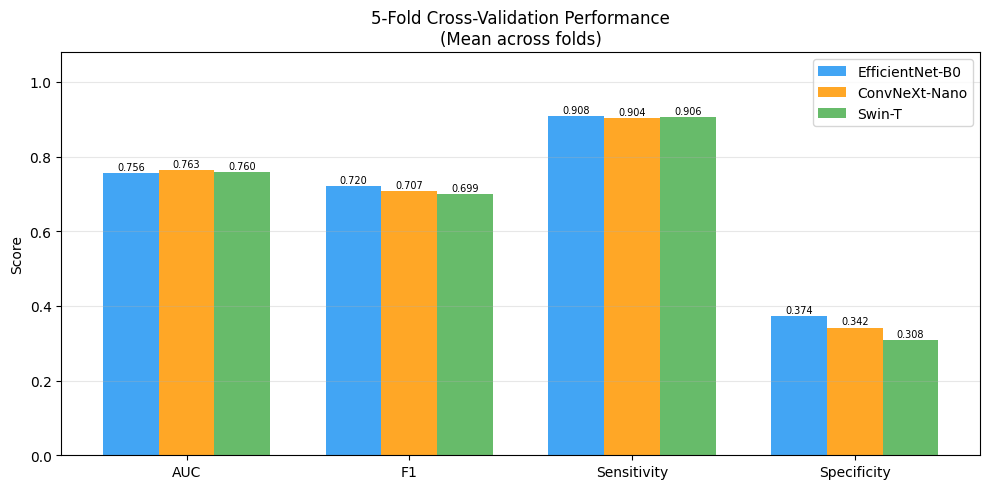

Saved nb07_cv_bar_chart.png


In [6]:
# Bar chart comparison for 5-fold CV metrics

cv_metrics_to_plot = ["auc", "f1", "sensitivity", "specificity"]
metric_labels = ["AUC", "F1", "Sensitivity", "Specificity"]

colors = ["#2196F3", "#FF9800", "#4CAF50"]

x = np.arange(len(cv_metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, color) in enumerate(zip(models, colors)):

    vals = [
        results[name]["cv_mean"][m]
        for m in cv_metrics_to_plot
    ]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=name,
        color=color,
        alpha=0.85
    )

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title(
    "5-Fold Cross-Validation Performance\n"
    "(Mean across folds)"
)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUT / "nb07_cv_bar_chart.png",
    dpi=150
)

plt.show()

print("Saved nb07_cv_bar_chart.png")

## 5. 5-fold CV AUC Comparison

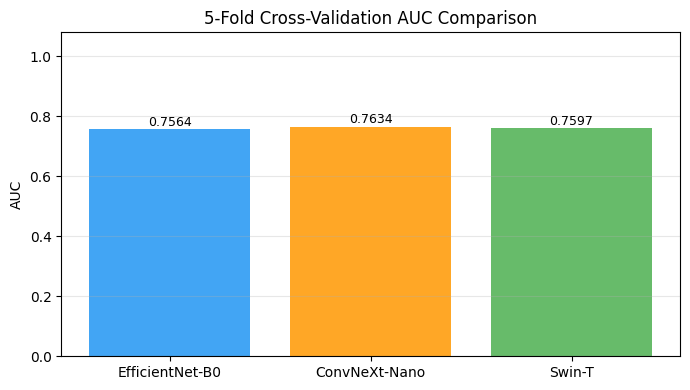

Saved nb07_cv_auc_comparison.png


In [7]:
# Shows overall cross-validation classification performance

fig, ax = plt.subplots(figsize=(7, 4))
cv_aucs = [
    results[n]["cv_mean"]["auc"]
    for n in models
]

bars = ax.bar(
    models,
    cv_aucs,
    color=colors,
    alpha=0.85
)

for bar, val in zip(bars, cv_aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(0, 1.08)
ax.set_ylabel("AUC")
ax.set_title("5-Fold Cross-Validation AUC Comparison")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUT / "nb07_cv_auc_comparison.png",
    dpi=150
)

plt.show()

print("Saved nb07_cv_auc_comparison.png")

## 6. Calibrated Threshold Comparison

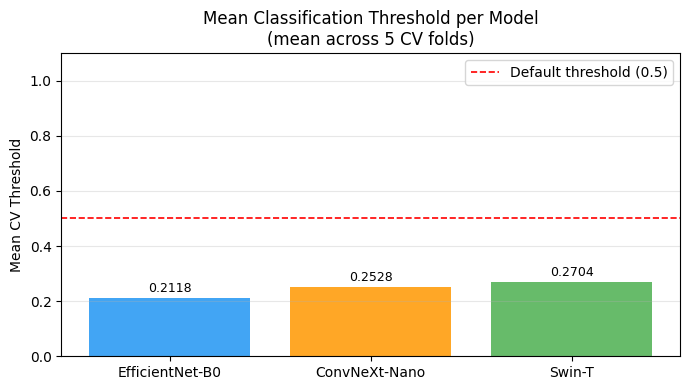

Saved nb07_threshold_comparison.png


In [8]:
# Threshold comparison plot
# Shows the mean threshold selected across the 5 CV folds

thresholds = [
    np.mean([
        fold["threshold"]
        for fold in results[n]["fold_results"]
    ])
    for n in models
]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    models,
    thresholds,
    color=colors,
    alpha=0.85
)

for bar, val in zip(bars, thresholds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.axhline(
    0.5,
    color="red",
    linestyle="--",
    lw=1.2,
    label="Default threshold (0.5)"
)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Mean CV Threshold")
ax.set_title(
    "Mean Classification Threshold per Model\n"
    "(mean across 5 CV folds)"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUT / "nb07_threshold_comparison.png",
    dpi=150
)

plt.show()

print("Saved nb07_threshold_comparison.png")

In [9]:
for name in models:
    thresholds = [
        fold["threshold"]
        for fold in results[name]["fold_results"]
    ]

    print(f"{name}:")
    print("  Fold thresholds:", [f"{x:.4f}" for x in thresholds])
    print(f"  Mean ± SD      : {np.mean(thresholds):.4f} ± {np.std(thresholds, ddof=1):.4f}")

EfficientNet-B0:
  Fold thresholds: ['0.1701', '0.1268', '0.2452', '0.2490', '0.2681']
  Mean ± SD      : 0.2118 ± 0.0605
ConvNeXt-Nano:
  Fold thresholds: ['0.2077', '0.2456', '0.3117', '0.1769', '0.3219']
  Mean ± SD      : 0.2528 ± 0.0634
Swin-T:
  Fold thresholds: ['0.2723', '0.3306', '0.3397', '0.2011', '0.2081']
  Mean ± SD      : 0.2704 ± 0.0654


## 7. Calibration Quality : ECE
Expected Calibration Error measures how well predicted probabilities 
match actual outcome frequencies. Lower is better.

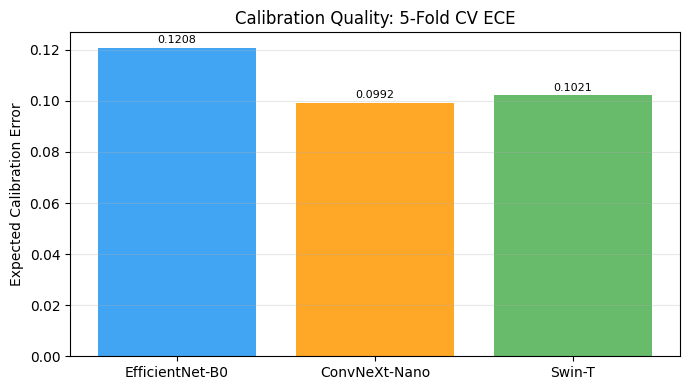

In [10]:
# ECE comparison (calibration quality)
# Lower ECE = better calibrated probability outputs
cv_eces = [results[n]["cv_mean"]["ece"] for n in models]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    models,
    cv_eces,
    color=colors,
    alpha=0.85
)

for bar, v in zip(bars, cv_eces):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.001,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models)
ax.set_ylabel("Expected Calibration Error")
ax.set_title("Calibration Quality: 5-Fold CV ECE")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUT / "nb07_ece_comparison.png",
    dpi=150
)

plt.show()

### 9. Results for Direct Comparison

In [13]:
# Results for direct juxtaposition
# Current JSON contains 5-fold CV results, not separate validation metrics.

print("\nThis Project Results\n")

comparison_results = [
    ("EfficientNet-B0", results["EfficientNet-B0"]),
    ("ConvNeXt-Nano",   results["ConvNeXt-Nano"]),
    ("Swin-T",          results["Swin-T"]),
]

col_w2 = [20, 14, 14, 16, 16, 14, 14]

headers2 = [
    "Model", "AUC", "F1",
    "Sensitivity", "Specificity", "FPR", "ECE"
]

print("".join(
    f"{h:<{w}}"
    for h, w in zip(headers2, col_w2)
))

print("-" * sum(col_w2))

for name, r in comparison_results:

    cm = r["cv_mean"]

    print(
        f"{name:<20}"
        f"{cm['auc']:<14.4f}"
        f"{cm['f1']:<14.4f}"
        f"{cm['sensitivity']:<16.4f}"
        f"{cm['specificity']:<16.4f}"
        f"{cm['fpr']:<14.4f}"
        f"{cm['ece']:<14.4f}"
    )

print("-" * sum(col_w2))

print("\nEval unit     : Patient/bag-level")
print("Eval strategy : 5-fold cross-validation")
print("Metrics       : Mean across 5 folds")


This Project Results

Model               AUC           F1            Sensitivity     Specificity     FPR           ECE           
------------------------------------------------------------------------------------------------------------
EfficientNet-B0     0.7564        0.7204        0.9077          0.3737          0.6263        0.1208        
ConvNeXt-Nano       0.7634        0.7074        0.9044          0.3423          0.6577        0.0992        
Swin-T              0.7597        0.6989        0.9061          0.3075          0.6925        0.1021        
------------------------------------------------------------------------------------------------------------

Eval unit     : Patient/bag-level
Eval strategy : 5-fold cross-validation
Metrics       : Mean across 5 folds


## 10. Save Comparison Summary
Export a flat JSON of key metrics for all three models

In [14]:
# Save comparison summary as JSON for use in later notebooks
# Current results contain 5-fold CV metrics.

summary = {}

for name, r in results.items():

    # Extract fold thresholds because threshold is stored per fold
    fold_thresholds = [
        fold["threshold"]
        for fold in r["fold_results"]
    ]

    summary[name] = {
        "feat_dim": r["feat_dim"],

        # Threshold statistics across folds
        "threshold_mean": float(np.mean(fold_thresholds)),
        "threshold_std": float(np.std(fold_thresholds, ddof=1)),

        # 5-fold CV mean
        "cv_mean": {
            key: float(value)
            for key, value in r["cv_mean"].items()
        },

        # 5-fold CV standard deviation
        "cv_std": {
            key: float(value)
            for key, value in r["cv_std"].items()
        },

        # Individual fold results
        "fold_results": r["fold_results"],
    }

with open(OUT / "nb07_baseline_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: nb07_baseline_summary.json")

Saved: nb07_baseline_summary.json


## 11. Final Ranking and Model Selection

In [15]:
# Final ranking printout (5-fold CV results)

print("\n" + "=" * 60)
print("  NB07: LEAK-FREE BASELINE COMPARISON SUMMARY")
print("=" * 60)

# ---------------------------------------------------------
# Ranking by CV AUC (higher is better)
# ---------------------------------------------------------
print("\n  Ranking by CV AUC:")

ranked = sorted(
    models,
    key=lambda n: results[n]["cv_mean"]["auc"],
    reverse=True
)

for i, name in enumerate(ranked, 1):
    auc = results[name]["cv_mean"]["auc"]
    print(f"    {i}. {name:<20} CV AUC = {auc:.4f}")


# ---------------------------------------------------------
# Ranking by CV F1 (higher is better)
# ---------------------------------------------------------
print("\n  Ranking by CV F1:")

ranked_f1 = sorted(
    models,
    key=lambda n: results[n]["cv_mean"]["f1"],
    reverse=True
)

for i, name in enumerate(ranked_f1, 1):
    f1 = results[name]["cv_mean"]["f1"]
    print(f"    {i}. {name:<20} CV F1  = {f1:.4f}")


# ---------------------------------------------------------
# Ranking by CV ECE (lower is better)
# ---------------------------------------------------------
print("\n  Ranking by CV ECE (lower is better):")

ranked_ece = sorted(
    models,
    key=lambda n: results[n]["cv_mean"]["ece"]
)

for i, name in enumerate(ranked_ece, 1):
    ece = results[name]["cv_mean"]["ece"]
    print(f"    {i}. {name:<20} CV ECE = {ece:.4f}")


# ---------------------------------------------------------
# Ranking by CV FPR (lower is better)
# ---------------------------------------------------------
print("\n  Ranking by CV FPR (lower is better):")

ranked_fpr = sorted(
    models,
    key=lambda n: results[n]["cv_mean"]["fpr"]
)

for i, name in enumerate(ranked_fpr, 1):
    fpr = results[name]["cv_mean"]["fpr"]
    print(f"    {i}. {name:<20} CV FPR = {fpr:.4f}")


print("=" * 60)


  NB07: LEAK-FREE BASELINE COMPARISON SUMMARY

  Ranking by CV AUC:
    1. ConvNeXt-Nano        CV AUC = 0.7634
    2. Swin-T               CV AUC = 0.7597
    3. EfficientNet-B0      CV AUC = 0.7564

  Ranking by CV F1:
    1. EfficientNet-B0      CV F1  = 0.7204
    2. ConvNeXt-Nano        CV F1  = 0.7074
    3. Swin-T               CV F1  = 0.6989

  Ranking by CV ECE (lower is better):
    1. ConvNeXt-Nano        CV ECE = 0.0992
    2. Swin-T               CV ECE = 0.1021
    3. EfficientNet-B0      CV ECE = 0.1208

  Ranking by CV FPR (lower is better):
    1. EfficientNet-B0      CV FPR = 0.6263
    2. ConvNeXt-Nano        CV FPR = 0.6577
    3. Swin-T               CV FPR = 0.6925
